In [1]:
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import display, HTML

# Добавляем CSS для глобального применения прокрутки к графикам
display(HTML("""
    <style>
        .scrollable-output {
            max-height: 300px;
            overflow-y: auto;
            border: 1px solid #ddd;
            padding: 5px;
        }
    </style>
"""))

def scrollable_plot(fig, height=400):
    """Выводит matplotlib figure в прокручиваемом контейнере"""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.getvalue()).decode()
    
    html = f"""
    <div class="scrollable-output" style="max-height: {height}px;">
        <img src="data:image/png;base64,{img_base64}">
    </div>
    """
    plt.close(fig)  # Закрываем фигуру, чтобы избежать двойного вывода
    display(HTML(html))

# Пример использования
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(range(10), range(10))
# scrollable_plot(fig)


In [61]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
plt.rcParams["image.cmap"] = 'magma'
import seaborn as sns
from tqdm.notebook import tqdm
from tabulate import tabulate

from sklearn.metrics.pairwise import cosine_similarity

from damo.config.base import parse_config
from tools.demo import Infer

from my_help_functions.hooks import register_conv_bn_hooks, register_bn_hooks
from my_help_functions.cosine_matrix import get_positions_of_classes_on_flattened_image, get_positions_of_classes_on_flattened_image_for_collage


In [62]:
config = parse_config('./configs/damoyolo_tinynasL20_T.py')

infer_engine = Infer(config, device='cpu',
    ckpt='./weights/damoyolo_tiny.pth')

model = infer_engine.model.eval()

Inference with torch engine!


In [3]:
# model.backbone.block_list[1].block_list[0].conv2.rbr_1x1.conv.weight.requires_grad # True
model.backbone.block_list[1].block_list[0].conv2.rbr_reparam_bn

ModuleAttributeError: 'RepConv' object has no attribute 'rbr_reparam_bn'

In [4]:
for name, layer in list(model.named_modules())[:1]:
    print(name, layer)

 Detector(
  (backbone): TinyNAS(
    (block_list): ModuleList(
      (0): Focus(
        (conv): ConvBNAct(
          (conv): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): ReLU(inplace=True)
        )
      )
      (1): SuperResStem(
        (act): ReLU(inplace=True)
        (block_list): ModuleList(
          (0): ResConvBlock(
            (conv1): ConvKXBN(
              (conv1): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
            )
            (conv2): RepConv(
              (nonlinearity): Identity()
              (rbr_reparam): Conv2d(24, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
            )
            (activation_function): ReLU(inplace=True)
          )
          (1): ResConvBlock(
            (co

In [5]:
savefig = True

idx = 5
path = f'./collage/gray_collage_background_centroid_{idx}.jpg'

In [6]:
bns, convs = register_conv_bn_hooks(model)
# bns = register_bn_hooks(model)

isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance
isinstance


In [7]:
origin_image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
image, origin_shape = infer_engine.preprocess(origin_image)
output = model(image)

add conv backbone.block_list.0.conv.conv
add bn backbone.block_list.0.conv.bn
add conv backbone.block_list.1.block_list.0.conv1.conv1
add bn backbone.block_list.1.block_list.0.conv1.bn1
add conv backbone.block_list.1.block_list.1.conv1.conv1
add bn backbone.block_list.1.block_list.1.conv1.bn1
add conv backbone.block_list.2.block_list.0.conv1.conv1
add bn backbone.block_list.2.block_list.0.conv1.bn1
add conv backbone.block_list.2.block_list.1.conv1.conv1
add bn backbone.block_list.2.block_list.1.conv1.bn1
add conv backbone.block_list.3.block_list.0.conv1.conv1
add bn backbone.block_list.3.block_list.0.conv1.bn1
add conv backbone.block_list.3.block_list.1.conv1.conv1
add bn backbone.block_list.3.block_list.1.conv1.bn1
add conv backbone.block_list.4.block_list.0.conv1.conv1
add bn backbone.block_list.4.block_list.0.conv1.bn1
add conv backbone.block_list.4.block_list.1.conv1.conv1
add bn backbone.block_list.4.block_list.1.conv1.bn1
add conv backbone.block_list.5.block_list.0.conv1.conv1
ad

In [40]:
len(bns)

47

In [39]:
from tabulate import tabulate

data = [(name, module, input.size(), output.size()) for name, module, input, output in bns]
print(tabulate(data, headers=["Название", "Слой", "Размер входа", "Размер выхода"], tablefmt="grid"))

+----------------------------------------------+-----------------------------------------------------------------------------------+----------------------------+----------------------------+
| Название                                     | Слой                                                                              | Размер входа               | Размер выхода              |
+==============================================+===================================================================================+============================+============================+
| backbone.block_list.0.conv.bn                | BatchNorm2d(24, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)  | torch.Size([24, 320, 320]) | torch.Size([24, 320, 320]) |
+----------------------------------------------+-----------------------------------------------------------------------------------+----------------------------+----------------------------+
| backbone.block_list.1.block_list.0.conv1.bn

In [10]:
dict(model.named_parameters()).keys()

dict_keys(['backbone.block_list.0.conv.conv.weight', 'backbone.block_list.0.conv.bn.weight', 'backbone.block_list.0.conv.bn.bias', 'backbone.block_list.1.block_list.0.conv1.conv1.weight', 'backbone.block_list.1.block_list.0.conv1.bn1.weight', 'backbone.block_list.1.block_list.0.conv1.bn1.bias', 'backbone.block_list.1.block_list.0.conv2.rbr_dense.conv.weight', 'backbone.block_list.1.block_list.0.conv2.rbr_dense.bn.weight', 'backbone.block_list.1.block_list.0.conv2.rbr_dense.bn.bias', 'backbone.block_list.1.block_list.0.conv2.rbr_1x1.conv.weight', 'backbone.block_list.1.block_list.0.conv2.rbr_1x1.bn.weight', 'backbone.block_list.1.block_list.0.conv2.rbr_1x1.bn.bias', 'backbone.block_list.1.block_list.1.conv1.conv1.weight', 'backbone.block_list.1.block_list.1.conv1.bn1.weight', 'backbone.block_list.1.block_list.1.conv1.bn1.bias', 'backbone.block_list.1.block_list.1.conv2.rbr_dense.conv.weight', 'backbone.block_list.1.block_list.1.conv2.rbr_dense.bn.weight', 'backbone.block_list.1.block_li

In [17]:
import torchviz
x = torch.randn(1, 3, *infer_engine.infer_size)
output, fpn_outs = model(x, stu=True)

dot = torchviz.make_dot(torch.Tensor(sum([pred.mean() for pred in output[0]])), params=dict(model.named_parameters()), )
dot.format = 'svg'
dot.render('model_arch_self.svg')


ExecutableNotFound: failed to execute 'dot', make sure the Graphviz executables are on your systems' PATH

In [16]:
sum([pred.mean() for pred in output[0]])

0

In [48]:
import re
from collections import defaultdict, deque

def clean_label(label):
    # # Удаляем всё после скобок (если есть)
    # label = re.sub(r'\s*\(.*?\)', '', label)
    # return label.strip()
    return label.split()[0].strip('"')

def parse_graphviz_file(file_path):
    edges = []  # Список ребер (id_from, id_to)
    labels = {}  # id -> label

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            edge_match = re.match(r'(\d+)\s*->\s*(\d+)', line)
            if edge_match:
                src, dst = edge_match.groups()
                edges.append((src, dst))
                continue

            label_match = re.match(r'(\d+)\s*\[label=(.+?)\]', line)
            if label_match:
                node_id, raw_label = label_match.groups()
                clean = clean_label(raw_label)
                labels[node_id] = clean

    return edges, labels

def build_graph(edges):
    forward = defaultdict(list)
    backward = defaultdict(list)
    for src, dst in edges:
        forward[src].append(dst)
        backward[dst].append(src)
    return forward, backward

def find_batchnorm_names(forward, backward, labels):
    batchnorm_map = {}

    for node_id, label in labels.items():
        if label != 'NativeBatchNormBackward0':
            continue

        # Ищем соседей назад (в AccumulateGrad)
        acc_nodes = backward.get(node_id, [])
        for acc in acc_nodes:
            if labels.get(acc) != 'AccumulateGrad':
                continue

            # Назад от AccumulateGrad, ищем узел с названием
            for candidate in backward.get(acc, []):
                name = labels.get(candidate)
                if name and 'bn' in name:
                    batchnorm_map[node_id] = '.'.join(name.split('.')[:-1])
                    break

            if node_id in batchnorm_map:
                break  # Достаточно одного имени

    return batchnorm_map

def bfs_batchnorm_connections(start_nodes, forward, labels, batchnorm_map):
    result = defaultdict(list)
    id_to_name = {v: k for k, v in batchnorm_map.items()}

    for src_id, src_name in batchnorm_map.items():
        visited = set()
        queue = deque([src_id])

        while queue:
            current = queue.popleft()
            for neighbor in forward.get(current, []):
                if neighbor in visited:
                    continue
                visited.add(neighbor)

                if neighbor in batchnorm_map and neighbor != src_id:
                    result[src_name].append(batchnorm_map[neighbor])
                else:
                    queue.append(neighbor)

    return result

# --- Пример использования ---
file_path = './architecture.txt'
edges, labels = parse_graphviz_file(file_path)
forward, backward = build_graph(edges)
batchnorm_map = find_batchnorm_names(forward, backward, labels)
connections = bfs_batchnorm_connections(batchnorm_map, forward, labels, batchnorm_map)

for bn_label, reachable_bn_labels in connections.items():
    print(f"{bn_label} -> {reachable_bn_labels}")


neck.merge_5.conv3.bn -> ['neck.bu_conv57.bn']
neck.merge_5.conv1.bn -> ['neck.merge_5.conv3.bn']
backbone.block_list.2.block_list.1.conv1.bn1 -> ['backbone.block_list.3.block_list.0.conv1.bn1', 'neck.bu_conv24.bn', 'neck.merge_5.conv1.bn', 'neck.merge_5.conv2.bn']
backbone.block_list.2.block_list.0.conv1.bn1 -> ['backbone.block_list.2.block_list.1.conv1.bn1', 'backbone.block_list.3.block_list.0.conv1.bn1', 'neck.bu_conv24.bn', 'neck.merge_5.conv1.bn', 'neck.merge_5.conv2.bn']
backbone.block_list.1.block_list.1.conv1.bn1 -> ['backbone.block_list.2.block_list.0.conv1.bn1']
backbone.block_list.1.block_list.0.conv1.bn1 -> ['backbone.block_list.1.block_list.1.conv1.bn1', 'backbone.block_list.2.block_list.0.conv1.bn1']
backbone.block_list.0.conv.bn -> ['backbone.block_list.1.block_list.0.conv1.bn1']
neck.merge_4.conv3.bn -> ['neck.bu_conv46.bn', 'neck.merge_7.conv1.bn', 'neck.merge_7.conv2.bn', 'neck.merge_5.conv1.bn', 'neck.merge_5.conv2.bn']
neck.merge_4.conv1.bn -> ['neck.merge_4.conv3.b

In [49]:
print(len(connections))

46


In [65]:
bns_fwd_names = [name for name, _, _, _ in bns]
bns_bfs_names = [k for k, v in connections.items()]

In [55]:
bns_fwd_names[0]

'backbone.block_list.0.conv.bn'

In [56]:
bns_bfs_names

['neck.merge_5.conv3.bn',
 'neck.merge_5.conv1.bn',
 'backbone.block_list.2.block_list.1.conv1.bn1',
 'backbone.block_list.2.block_list.0.conv1.bn1',
 'backbone.block_list.1.block_list.1.conv1.bn1',
 'backbone.block_list.1.block_list.0.conv1.bn1',
 'backbone.block_list.0.conv.bn',
 'neck.merge_4.conv3.bn',
 'neck.merge_4.conv1.bn',
 'backbone.block_list.4.block_list.1.conv1.bn1',
 'backbone.block_list.4.block_list.0.conv1.bn1',
 'backbone.block_list.3.block_list.1.conv1.bn1',
 'backbone.block_list.3.block_list.0.conv1.bn1',
 'neck.bu_conv24.bn',
 'neck.merge_3.conv3.bn',
 'neck.merge_3.conv1.bn',
 'backbone.block_list.5.block_list.1.conv2.bn',
 'backbone.block_list.5.block_list.1.conv1.bn',
 'backbone.block_list.5.block_list.0.conv1.bn1',
 'neck.bu_conv13.bn',
 'neck.merge_3.conv2.bn',
 'neck.merge_3.convs.0.conv1.bn',
 'neck.merge_3.convs.1.conv1.bn',
 'neck.merge_3.convs.2.conv1.bn',
 'neck.merge_4.conv2.bn',
 'neck.merge_4.convs.0.conv1.bn',
 'neck.merge_4.convs.1.conv1.bn',
 'neck.

In [66]:
for b in bns_fwd_names:
    if b not in bns_bfs_names:
        print(b)

In [63]:
connections['neck.merge_6.conv3.bn'] = []

In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_dependency_graph(node_connections):
    # Уникальные узлы (сохраняем порядок появления)
    all_nodes = list(dict.fromkeys(
        list(node_connections.keys()) + 
        [n for v in node_connections.values() for n in v]
    ))
    node_index = {name: idx for idx, name in enumerate(all_nodes)}

    fig, ax = plt.subplots(figsize=(max(12, len(all_nodes) * 0.5), 6))

    # Рисуем точки (узлы) на горизонтальной линии
    for name, x in node_index.items():
        ax.plot(x, 0, 'o', color='black')
        ax.text(x, -0.3, name, rotation=90, ha='center', va='top', fontsize=7)

    # Сохраняем используемые высоты, чтобы не пересекать
    used_arcs = {}

    def find_free_height(x1, x2):
        for h in range(1, len(all_nodes)):
            if all((i, h) not in used_arcs for i in range(x1, x2)):
                for i in range(x1, x2):
                    used_arcs[(i, h)] = True
                return h * 0.3
        return 1  # fallback

    # Рисуем связи
    for src, dsts in node_connections.items():
        x1 = node_index[src]
        for dst in dsts:
            x2 = node_index[dst]
            if x1 == x2:
                continue
            left, right = sorted((x1, x2))
            height = find_free_height(left, right)
            arc = patches.Arc(
                xy=((x1 + x2)/2, 0),
                width=abs(x2 - x1),
                height=height,
                theta1=0, theta2=180,
                edgecolor='blue'
            )
            ax.add_patch(arc)

    ax.axis('off')
    plt.tight_layout()
    plt.show()


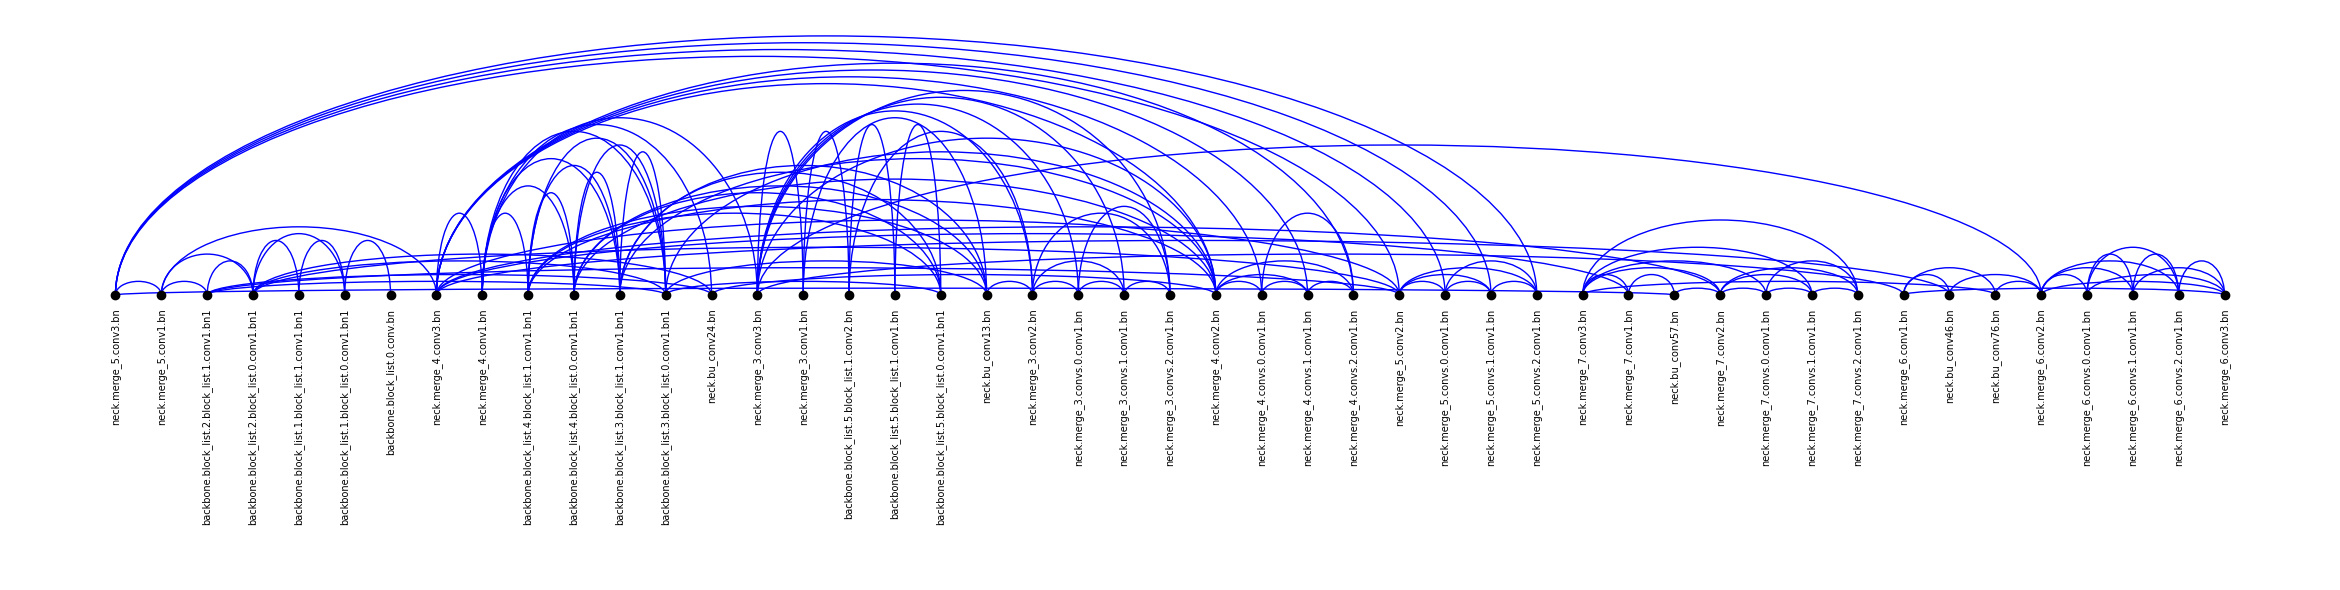

In [60]:
plot_dependency_graph(connections)

In [67]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_bn_graph(bn_connections: dict, bns_fwd_names: list):
    # Создаём направленный граф
    G = nx.DiGraph()

    # Добавляем только нужные узлы и дуги
    for src in bn_connections:
        if src not in bns_fwd_names:
            continue
        for dst in bn_connections[src]:
            if dst not in bns_fwd_names:
                continue
            idx_src = bns_fwd_names.index(src)
            idx_dst = bns_fwd_names.index(dst)
            if abs(idx_src - idx_dst) == 1:
                # Пропускаем дугу между соседними вершинами
                continue
            G.add_edge(src, dst)

    # Позиции узлов на одной горизонтальной линии
    pos = {name: (i, 0) for i, name in enumerate(bns_fwd_names)}

    # Отфильтровываем узлы без рёбер, если они не участвуют в графе
    active_nodes = set()
    for u, v in G.edges:
        active_nodes.add(u)
        active_nodes.add(v)
    pos = {k: v for k, v in pos.items() if k in active_nodes}

    # Рисуем граф
    plt.figure(figsize=(max(12, len(pos) * 0.5), 3))
    nx.draw(
        G, pos,
        with_labels=False,
        node_size=10,
        edge_color="gray",
        arrows=True,
        connectionstyle="arc3,rad=0.2"
    )

    # Отдельно рисуем подписи с поворотом
    for node, (x, y) in pos.items():
        plt.text(x, y - 0.2, node, fontsize=7, rotation=90, ha='center', va='top')

    plt.axis('off')
    plt.tight_layout()
    plt.show()


c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


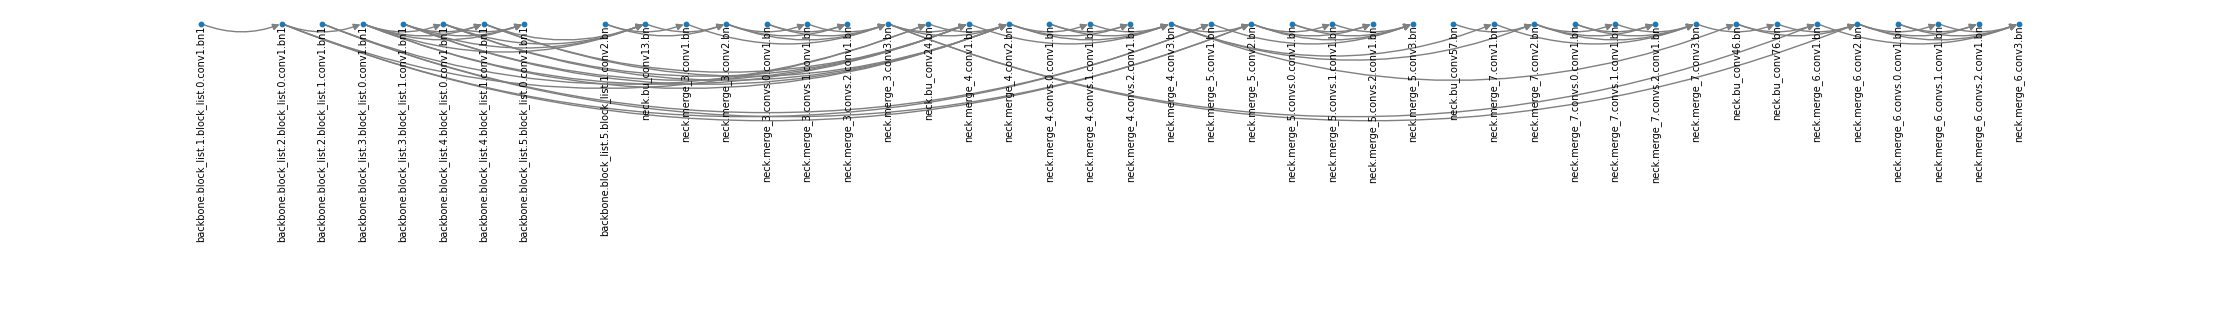

In [68]:
visualize_bn_graph(connections, bns_fwd_names)

In [69]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_bn_graph_2(bn_connections: dict, bns_fwd_names: list):
    # Только те узлы, которые входят в bns_fwd_names
    allowed_nodes = set(bns_fwd_names)

    # Создаём направленный граф
    G = nx.DiGraph()

    for src in bn_connections:
        if src not in allowed_nodes:
            continue
        for dst in bn_connections[src]:
            if dst not in allowed_nodes:
                continue
            idx_src = bns_fwd_names.index(src)
            idx_dst = bns_fwd_names.index(dst)
            if abs(idx_src - idx_dst) == 1:
                continue  # Пропускаем дуги между соседними узлами
            G.add_edge(src, dst)

    # Позиции по горизонтали
    pos = {name: (i, 0) for i, name in enumerate(bns_fwd_names) if name in G.nodes}

    # Рисуем граф
    plt.figure(figsize=(max(12, len(pos) * 0.5), 3))
    nx.draw(
        G, pos,
        with_labels=False,
        node_size=10,
        edge_color="gray",
        arrows=True,
        connectionstyle="arc3,rad=0.2"
    )

    # Подписи узлов вертикально
    for node, (x, y) in pos.items():
        plt.text(x, y - 0.2, node, fontsize=7, rotation=90, ha='center', va='top')

    plt.axis('off')
    plt.tight_layout()
    plt.show()


c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


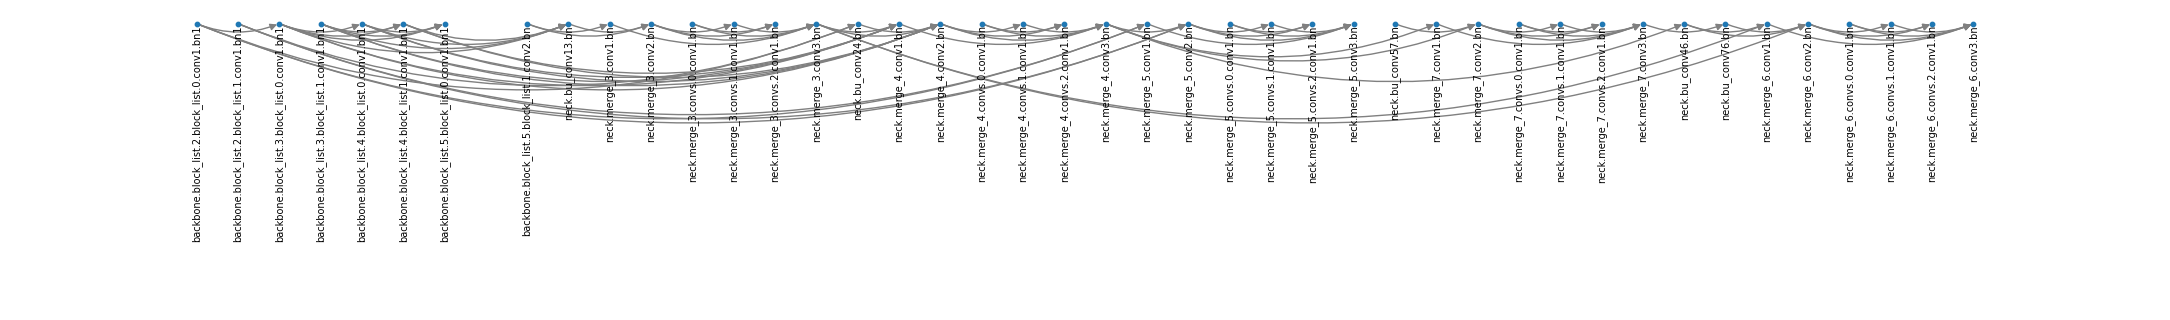

In [76]:
visualize_bn_graph_2(connections, bns_fwd_names[2:])

In [74]:
bns_fwd_names

['backbone.block_list.0.conv.bn',
 'backbone.block_list.1.block_list.0.conv1.bn1',
 'backbone.block_list.1.block_list.1.conv1.bn1',
 'backbone.block_list.2.block_list.0.conv1.bn1',
 'backbone.block_list.2.block_list.1.conv1.bn1',
 'backbone.block_list.3.block_list.0.conv1.bn1',
 'backbone.block_list.3.block_list.1.conv1.bn1',
 'backbone.block_list.4.block_list.0.conv1.bn1',
 'backbone.block_list.4.block_list.1.conv1.bn1',
 'backbone.block_list.5.block_list.0.conv1.bn1',
 'backbone.block_list.5.block_list.1.conv1.bn',
 'backbone.block_list.5.block_list.1.conv2.bn',
 'neck.bu_conv13.bn',
 'neck.merge_3.conv1.bn',
 'neck.merge_3.conv2.bn',
 'neck.merge_3.convs.0.conv1.bn',
 'neck.merge_3.convs.1.conv1.bn',
 'neck.merge_3.convs.2.conv1.bn',
 'neck.merge_3.conv3.bn',
 'neck.bu_conv24.bn',
 'neck.merge_4.conv1.bn',
 'neck.merge_4.conv2.bn',
 'neck.merge_4.convs.0.conv1.bn',
 'neck.merge_4.convs.1.conv1.bn',
 'neck.merge_4.convs.2.conv1.bn',
 'neck.merge_4.conv3.bn',
 'neck.merge_5.conv1.bn',

#  Дальше не лезем

In [ ]:
before_conv = np.array([convs[i][1].detach().cpu() for i in range(len(bns))])
after_conv = np.array([convs[i][2].detach().cpu() for i in range(len(bns))])

c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  """Entry point for launching an IPython kernel.
c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.
c:\Users\asche

In [ ]:
before_conv[0].shape

torch.Size([12, 320, 320])

In [ ]:
after_center = np.array([bns[i][1].detach().cpu() - bns[i][0].running_mean.view(-1, 1, 1).detach().cpu() for i in range(len(bns))])

c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  """Entry point for launching an IPython kernel.
c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.


In [ ]:
for i in range(len(after_conv)):
    print(before_conv[i].shape, after_conv[i].shape, after_center[i].shape)

torch.Size([12, 320, 320]) torch.Size([24, 320, 320]) torch.Size([24, 320, 320])
torch.Size([24, 320, 320]) torch.Size([24, 320, 320]) torch.Size([24, 320, 320])
torch.Size([24, 320, 320]) torch.Size([64, 160, 160]) torch.Size([64, 160, 160])
torch.Size([24, 320, 320]) torch.Size([64, 160, 160]) torch.Size([64, 160, 160])
torch.Size([64, 160, 160]) torch.Size([24, 160, 160]) torch.Size([24, 160, 160])
torch.Size([24, 160, 160]) torch.Size([64, 160, 160]) torch.Size([64, 160, 160])
torch.Size([24, 160, 160]) torch.Size([64, 160, 160]) torch.Size([64, 160, 160])
torch.Size([64, 160, 160]) torch.Size([64, 160, 160]) torch.Size([64, 160, 160])
torch.Size([64, 160, 160]) torch.Size([96, 80, 80]) torch.Size([96, 80, 80])
torch.Size([64, 160, 160]) torch.Size([96, 80, 80]) torch.Size([96, 80, 80])
torch.Size([96, 80, 80]) torch.Size([64, 80, 80]) torch.Size([64, 80, 80])
torch.Size([64, 80, 80]) torch.Size([96, 80, 80]) torch.Size([96, 80, 80])
torch.Size([64, 80, 80]) torch.Size([96, 80, 80]

In [ ]:
import torch.nn.functional as F

def pairwise_cosine_similarity(x1, x2):
    x1 = F.normalize(x1, dim=0)
    x2 = F.normalize(x2, dim=0)
    return x1.T @ x2

In [ ]:
inside = []
outside = []
back = []

q = torch.Tensor([0.05, 0.25, 0.5, 0.75, 0.95])

for k in tqdm(range(2, len(after_center))):
# for k in range(2, 3):
    # positions, class_names = get_positions_of_classes_on_flattened_image_for_collage(idx, after_center[k].size()[1], "gray_", "background_centroid_")
    positions, class_names = get_positions_of_classes_on_flattened_image_for_collage(idx, after_center[k].size()[1], "gray_")

    # if before_conv[k].size()[1] != after_conv[k].size()[1]:
    #     # a = after_conv[k].copy()
    #     u = torch.nn.Upsample(scale_factor=2, mode='bilinear')
    #     a = u(after_conv[k].unsqueeze(0)).squeeze()
    #     matr1 = a.flatten(1, 2).detach()
    # else:
    #     matr1 = after_conv[k].flatten(1, 2).detach()
    # matr2 = before_conv[k].flatten(1, 2).detach()
    matr = after_center[k].flatten(1, 2).detach()

    # csm = pairwise_cosine_similarity(matr1, matr1) - pairwise_cosine_similarity(matr2, matr2) # torch.tensor
    csm = pairwise_cosine_similarity(matr, matr)# torch.tensor
    n = len(positions)

    mean_angle_change_w_others_list = []
    angle_change_w_self_list = []
    angle_change_w_back_list = []

    for i in range(n - 1):
    # Для 1 класса
    # for i in range(1):

        # mean_angle_change_w_others = 0
        # angle_change_w_self = 0
        # angle_change_w_back = 0
        mean_angle_change_w_others_list_inner = []
        angle_change_w_self_list_inner = []
        angle_change_w_back_list_inner = []
        
        for j in range(n):
            pos_i = torch.tensor(positions[i + 1], device=csm.device)
            pos_j = torch.tensor(positions[j + 1], device=csm.device)
            pair_matrix = torch.meshgrid(pos_i, pos_j)
            submatrix = csm[pair_matrix[0], pair_matrix[1]]

            # mean = submatrix.mean()
            quantiles = torch.quantile(submatrix.flatten(), q)
            
            if i == j:
                # angle_change_w_self_list.append(mean)
                angle_change_w_self_list_inner.append(quantiles)
                # angle_change_w_self = mean
            elif j == (n - 1):
                # angle_change_w_back_list.append(mean)
                angle_change_w_back_list_inner.append(quantiles)
                # angle_change_w_back = mean
            else:
                # mean_angle_change_w_others += mean
                mean_angle_change_w_others_list_inner.append(quantiles)
        
        # mean_angle_change_w_others /= (n - 2)
        # mean_angle_change_w_others_list.append(mean_angle_change_w_others)
        angle_change_w_self_list.append(torch.stack(angle_change_w_self_list_inner).mean(dim=0))
        angle_change_w_back_list.append(torch.stack(angle_change_w_back_list_inner).mean(dim=0))
        mean_angle_change_w_others_list.append(torch.stack(mean_angle_change_w_others_list_inner).mean(dim=0))

    # inside.append(torch.tensor(angle_change_w_self_list).mean())
    # outside.append(torch.tensor(mean_angle_change_w_others_list).mean())
    # back.append(torch.tensor(angle_change_w_back_list).mean())
    
    inside.append(torch.stack(angle_change_w_self_list).mean(dim=0))
    outside.append(torch.stack(mean_angle_change_w_others_list).mean(dim=0))
    back.append(torch.stack(angle_change_w_back_list).mean(dim=0))


  0%|          | 0/93 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=2.38s)
creating index...
index created!
loading annotations into memory...
Done (t=1.97s)
creating index...
index created!
loading annotations into memory...
Done (t=1.96s)
creating index...
index created!
loading annotations into memory...
Done (t=1.92s)
creating index...
index created!
loading annotations into memory...
Done (t=0.79s)
creating index...
index created!
loading annotations into memory...
Done (t=2.61s)
creating index...
index created!
loading annotations into memory...
Done (t=0.69s)
creating index...
index created!
loading annotations into memory...
Done (t=0.77s)
creating index...
index created!
loading annotations into memory...
Done (t=0.69s)
creating index...
index created!
loading annotations into memory...
Done (t=0.74s)
creating index...
index created!
loading annotations into memory...
Done (t=0.76s)
creating index...
index created!
loading annotations into memory...
Done (t=0.67s)
creating index...
index created!
load

In [ ]:
inside, outside, back

([tensor([-0.8005, -0.3474,  0.2549,  0.6663,  0.8977]),
  tensor([-0.9560, -0.5545,  0.3821,  0.8872,  0.9844]),
  tensor([-0.3397, -0.0491,  0.1745,  0.4170,  0.7102]),
  tensor([-0.1698,  0.0826,  0.2538,  0.4180,  0.6395]),
  tensor([-0.4102,  0.0467,  0.3376,  0.6044,  0.8468]),
  tensor([-0.3011, -0.0869,  0.0845,  0.2655,  0.5224]),
  tensor([-0.2088,  0.0122,  0.1814,  0.3629,  0.6275]),
  tensor([-0.6360, -0.1454,  0.2624,  0.6223,  0.8853]),
  tensor([-0.3062, -0.0761,  0.1222,  0.3338,  0.6224]),
  tensor([-0.3495, -0.0578,  0.1581,  0.3643,  0.6407]),
  tensor([-0.6063, -0.1604,  0.2623,  0.5850,  0.8538]),
  tensor([-0.2615, -0.0534,  0.1086,  0.2817,  0.5272]),
  tensor([-0.2704,  0.0229,  0.1935,  0.3654,  0.6429]),
  tensor([-0.5668, -0.0828,  0.2703,  0.5543,  0.8299]),
  tensor([-0.2526, -0.0119,  0.1823,  0.3914,  0.7068]),
  tensor([-0.3784,  0.0356,  0.3172,  0.5317,  0.7634]),
  tensor([-0.5948, -0.1434,  0.4451,  0.7831,  0.9303]),
  tensor([-0.2182, -0.0576,  0.

In [ ]:
def scale(X, mini, maxi, range_=(-1, 1)):
    min_, max_ = range_
    X = np.array(X)
    X_std = (X - mini) / (maxi - mini)
    X_scaled = X_std * (max_ - min_) + min_
    return X_scaled

# a_min = min(np.min(inside), np.min(outside), np.min(back))
# a_max = max(np.max(inside), np.max(outside), np.max(back))
# inside_scaled = scale(inside, a_min, a_max)
# outside_scaled = scale(outside, a_min, a_max)
# back_scaled = scale(back, a_min, a_max)


In [ ]:
inside_np = torch.stack(inside).cpu().numpy()  # (95, 5)
outside_np = torch.stack(outside).cpu().numpy()  # (95, 5)
back_np = torch.stack(back).cpu().numpy()  # (95, 5)

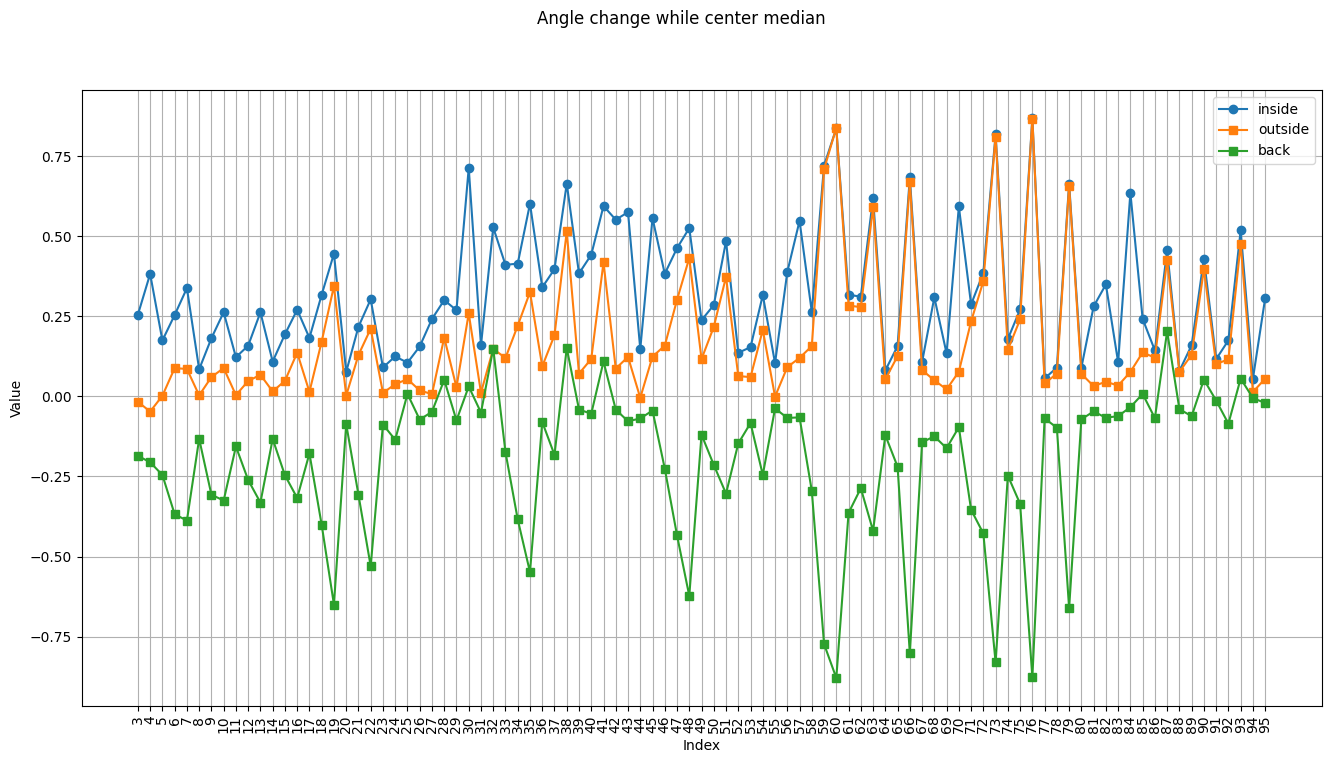

In [ ]:
x = np.arange(3, len(before_conv) + 1)

plt.figure(figsize=(16, 8))

plt.plot(x, inside_np[:, 2], marker='o', label='inside', linestyle='-')
plt.plot(x, outside_np[:, 2],  marker='s', label='outside', linestyle='-')
plt.plot(x, back_np[:, 2],  marker='s', label='back', linestyle='-')

plt.xticks(x, [str(i) for i in x], rotation=90)

# plt.axvline(x=30.5, color='black', linestyle='--')

# plt.text(10, 0.8, 'Backbone', ha='right', fontsize=12)
# plt.text(40, 0.8, 'Neck', ha='left', fontsize=12)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.suptitle("Angle change while center median")
# if savefig: plt.savefig("18.10. Изменение углов по всей модели при свёртке.png")
plt.show();


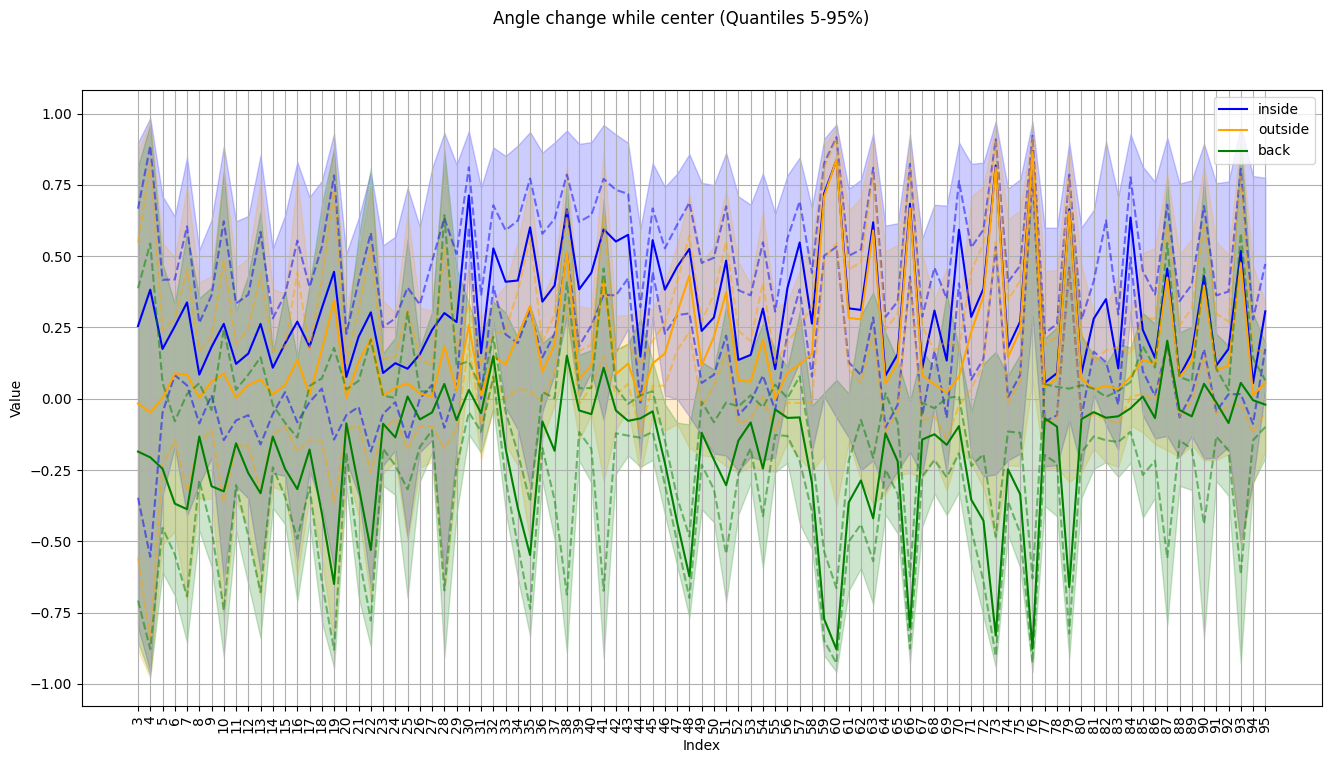

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(3, len(before_conv) + 1)

# inside = torch.stack(inside).cpu().numpy()  # (95, 5)
# outside = torch.stack(outside).cpu().numpy()
# back = torch.stack(back).cpu().numpy()

plt.figure(figsize=(16, 8))

# Функция для отрисовки трубки + линий
def plot_with_quantiles(x, quantiles, label, color):
    q05 = quantiles[:, 0]
    q25 = quantiles[:, 1]
    q50 = quantiles[:, 2]
    q75 = quantiles[:, 3]
    q95 = quantiles[:, 4]
    
    # Трубка между 5% и 95%
    plt.fill_between(x, q05, q95, alpha=0.2, color=color)
    
    # Дополнительно 25%-75%
    plt.plot(x, q25, linestyle='--', color=color, alpha=0.5)
    plt.plot(x, q75, linestyle='--', color=color, alpha=0.5)

    # Основная линия медианы
    plt.plot(x, q50, label=label, color=color)

# Рисуем все 3 серии
plot_with_quantiles(x, inside_np, label='inside', color='blue')
plot_with_quantiles(x, outside_np, label='outside', color='orange')
plot_with_quantiles(x, back_np, label='back', color='green')

plt.xticks(x, [str(i) for i in x], rotation=90)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.suptitle("Angle change while center (Quantiles 5-95%)")
plt.show()


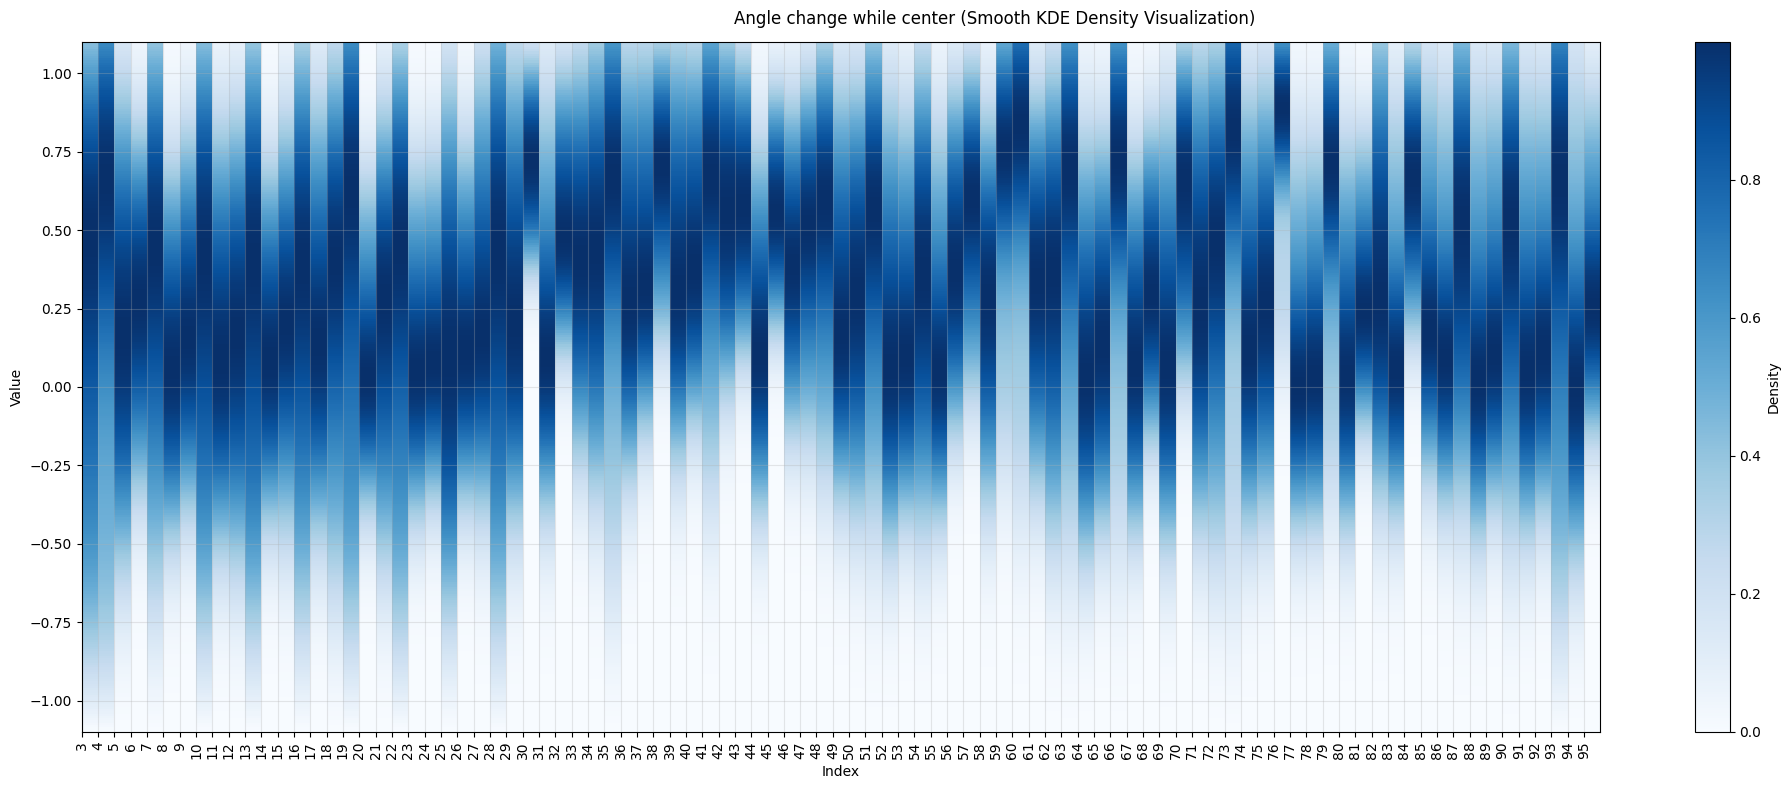

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Переводим в numpy
inside_np = torch.stack(inside).cpu().numpy()  # (95, 5)

# Настроим сетку для pcolormesh
x_grid = np.arange(len(inside_np) + 1)  # +1 для pcolormesh
y_grid = np.linspace(-1.1, 1.1, 300)    # Плавная сетка по Y (больше точек — плавнее)

# Подготовим матрицу плотностей
density_matrix = np.zeros((len(y_grid)-1, len(inside_np)))

# Считаем KDE для каждого объекта
for idx, quantiles in enumerate(inside_np):
    kde = gaussian_kde(quantiles)
    density_vals = kde(y_grid)
    
    # Нормализуем плотность в 0..1
    density_vals = (density_vals - np.min(density_vals)) / (np.max(density_vals) - np.min(density_vals) + 1e-8)

    density_matrix[:, idx] = density_vals[:-1]  # оставляем на один меньше для pcolormesh

# Теперь рисуем
plt.figure(figsize=(20, 8))

# Красивая заливка
plt.pcolormesh(x_grid, y_grid, density_matrix, cmap='Blues', shading='auto')

plt.colorbar(label='Density')
plt.xlabel('Index')
plt.ylabel('Value')
plt.xticks(np.arange(len(inside_np)), [str(i) for i in np.arange(3, len(before_conv) + 1)], rotation=90)
plt.suptitle('Angle change while center (Smooth KDE Density Visualization)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
